### ***County Grouping -- Simplified Feature Space (6 Features)***

In [1]:
# Setup 
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

In [3]:
import pandas as pd

# Populated data from Table 1 for 14-day Sakoe-Chiba Band
# Periods 7/14/21 only

data = {
    "County": [
        "Albany", "Big Horn", "Campbell", "Carbon", "Converse", "Crook",
        "Fremont", "Goshen", "Hot Springs", "Johnson", "Laramie", "Lincoln",
        "Natrona", "Niobrara", "Park", "Platte", "Sheridan", "Sublette",
        "Sweetwater", "Teton", "Uinta", "Washakie", "Weston"
    ],

    # ---- Median lag (days): negative => mobility leads; positive => cases lead ----
    "Lag_7_pre":   [-7, -4, -4, 0, -4, -6, -5, 11, 7, -7, 1, -7, -5, 0, -5, -10, 0, -5, -6, -7, -5, 2, 6],
    "Lag_14_pre":  [-4, -3, -6, 11, -5, -8, 0, 3, -4, -2, 3, -1, 5, 2, 5, 4, -2, 4, 1, -5, 2, -4, -2],
    "Lag_21_pre":  [-6, -8, 1, -10, -7, 0, -8, -11, -4, -9, -9, -13, -3, 12, -2, -3, -9, -6, 2, -3, -10, 1, -13],

    "Lag_7_post":  [-3, -2, -4, -4, -4, -3, 4, -2.5, -4, -13, -7, 1, -7, -8, -4, -2, -9, -4, -1, 3, 0, -7, 0],
    "Lag_14_post": [-4, -7, 3, -4, -3, 0, 1, 0, 6, 0, 5, -6.5, 0, 9, -4, 3, -3, 11, 2.5, -1, -3, 0, 2],
    "Lag_21_post": [-13, 5, -7, -6, -2, -12, -0.5, 11, -1, 3, 3, 12, -4.5, 4, -9, -1, -2, -11, -5, -13, -11, -13, -5],

    # ---- Normalized DTW distance ----
    "Dist_7_pre": [
        0.040063565, 0.052193767, 0.049656564, 0.054737698, 0.049876001,
        0.056353783, 0.042628931, 0.056189593, 0.052732221, 0.054200084,
        0.052160542, 0.050202752, 0.047969303, 0.057258979, 0.051631628,
        0.055984592, 0.045129581, 0.047624333, 0.049550661, 0.054611821,
        0.051845014, 0.049503346, 0.042369442
    ],

    "Dist_14_pre": [
        0.053030461, 0.053347186, 0.048938456, 0.037971746, 0.046378205,
        0.050114722, 0.055542005, 0.054940771, 0.054505565, 0.053709170,
        0.044535265, 0.047258282, 0.051121003, 0.055301319, 0.053369017,
        0.054393567, 0.054535630, 0.046769425, 0.039623813, 0.044922769,
        0.042357561, 0.048732849, 0.051233978
    ],

    "Dist_21_pre": [
        0.037441949, 0.054459555, 0.040072653, 0.044308064, 0.037881251,
        0.038378772, 0.037525518, 0.050077489, 0.057635063, 0.056564725,
        0.050742479, 0.055663999, 0.046842018, 0.055767454, 0.023565940,
        0.050741097, 0.055706486, 0.032935619, 0.047488878, 0.049946924,
        0.036097317, 0.036034941, 0.043409771
    ],

    "Dist_7_post": [
        0.072731919, 0.070512990, 0.070902667, 0.074105573, 0.071841045,
        0.064931411, 0.074098577, 0.073873590, 0.073366435, 0.070647893,
        0.072621713, 0.066166916, 0.072467145, 0.065897292, 0.066299370,
        0.041075227, 0.066012488, 0.070643955, 0.067943066, 0.067678504,
        0.068636220, 0.067429580, 0.071330302
    ],

    "Dist_14_post": [
        0.071319357, 0.060491220, 0.069097863, 0.072751593, 0.072908224,
        0.056482446, 0.068061890, 0.070989729, 0.070133607, 0.073592310,
        0.062201316, 0.066868625, 0.066893520, 0.056073608, 0.073210253,
        0.066051227, 0.065837758, 0.067687021, 0.069942249, 0.064030563,
        0.070661022, 0.065643457, 0.064492679
    ],

    "Dist_21_post": [
        0.075945151, 0.056195499, 0.069119812, 0.071014372, 0.068129822,
        0.063309785, 0.074644535, 0.074411315, 0.072987426, 0.065219258,
        0.070584925, 0.055010857, 0.066517640, 0.065657627, 0.054257865,
        0.050632680, 0.053174074, 0.050813429, 0.064351796, 0.070667458,
        0.054638141, 0.072279956, 0.075050769
    ],

    # ---- Mobility lead proportion ----
    "Mob_7_pre": [
        0.620071685, 0.558323896, 0.541062802, 0.486516854, 0.566125290,
        0.637472284, 0.588901472, 0.270136307, 0.239955357, 0.596871239,
        0.476689977, 0.605769231, 0.663378545, 0.474495848, 0.570071259,
        0.667058824, 0.494623656, 0.582022472, 0.639233371, 0.533249686,
        0.583821805, 0.405988024, 0.337962963
    ],

    "Mob_14_pre": [
        0.565565566, 0.553530752, 0.622471910, 0.206385405, 0.620885358,
        0.667812142, 0.497737557, 0.424719101, 0.544566545, 0.527412281,
        0.425485961, 0.508714597, 0.348810872, 0.443951165, 0.402537486,
        0.394931362, 0.528697572, 0.375846501, 0.477094972, 0.612829324,
        0.426580922, 0.635869565, 0.566703418
    ],

    "Mob_21_pre": [
        0.609783845, 0.587244284, 0.459016393, 0.629940120, 0.584049080,
        0.497613365, 0.630609896, 0.681924883, 0.529265255, 0.660115607,
        0.713800905, 0.671068427, 0.545997611, 0.348427673, 0.525330396,
        0.568398727, 0.646778043, 0.587443946, 0.428571429, 0.546576880,
        0.655380895, 0.456666667, 0.662949195
    ],

    "Mob_7_post": [
        0.557932264, 0.532062392, 0.596638655, 0.557491289, 0.597582038,
        0.583870968, 0.321299639, 0.546979866, 0.600343053, 0.728904847,
        0.656419530, 0.466165414, 0.628318584, 0.727574751, 0.594594595,
        0.548686244, 0.698384201, 0.605263158, 0.513464991, 0.352542373,
        0.476021314, 0.643356643, 0.469622332
    ],

    "Mob_14_post": [
        0.578583765, 0.655652174, 0.381112985, 0.561312608, 0.546247818,
        0.492385787, 0.453736655, 0.496677741, 0.318936877, 0.455830389,
        0.336936937, 0.678694158, 0.496666667, 0.266666667, 0.569230769,
        0.416107383, 0.582322357, 0.222222222, 0.431578947, 0.510273973,
        0.546391753, 0.491588785, 0.406137184
    ],

    "Mob_21_post": [
        0.858800774, 0.384321224, 0.651943463, 0.561904762, 0.521150592,
        0.767148014, 0.500000000, 0.256756757, 0.510805501, 0.390784983,
        0.430769231, 0.278095238, 0.597602740, 0.399267399, 0.659889094,
        0.505415162, 0.518987342, 0.722222222, 0.571948998, 0.684210526,
        0.712746858, 0.776091082, 0.574952562
    ],
}

df_full = pd.DataFrame(data).set_index("County")
df_full.head()

,Lag_7_pre,Lag_14_pre,Lag_21_pre,Lag_7_post,Lag_14_post,Lag_21_post,Dist_7_pre,Dist_14_pre,Dist_21_pre,Dist_7_post,Dist_14_post,Dist_21_post,Mob_7_pre,Mob_14_pre,Mob_21_pre,Mob_7_post,Mob_14_post,Mob_21_post
County,,,,,,,,,,,,,,,,,,
Albany,-7,-4,-6,-3.0,-4.0,-13.0,0.040064,0.053030,0.037442,0.072732,0.071319,0.075945,0.620072,0.565566,0.609784,0.557932,0.578584,0.858801
Big Horn,-4,-3,-8,-2.0,-7.0,5.0,0.052194,0.053347,0.054460,0.070513,0.060491,0.056195,0.558324,0.553531,0.587244,0.532062,0.655652,0.384321
Campbell,-4,-6,1,-4.0,3.0,-7.0,0.049657,0.048938,0.040073,0.070903,0.069098,0.069120,0.541063,0.622472,0.459016,0.596639,0.381113,0.651943
Carbon,0,11,-10,-4.0,-4.0,-6.0,0.054738,0.037972,0.044308,0.074106,0.072752,0.071014,0.486517,0.206385,0.629940,0.557491,0.561313,0.561905
Converse,-4,-5,-7,-4.0,-3.0,-2.0,0.049876,0.046378,0.037881,0.071841,0.072908,0.068130,0.566125,0.620885,0.584049,0.597582,0.546248,0.521151


### ***Construct the 6 Simplified Features***

In [ ]:
# --- Build 6-feature dataframe ---

df6 = pd.DataFrame(index=df_full.index)

df6["Lag_pre_mean"]  = df_full[["Lag_7_pre", "Lag_14_pre", "Lag_21_pre"]].mean(axis=1)
df6["Lag_post_mean"] = df_full[["Lag_7_post", "Lag_14_post", "Lag_21_post"]].mean(axis=1)

df6["Dist_pre_mean"]  = df_full[["Dist_7_pre", "Dist_14_pre", "Dist_21_pre"]].mean(axis=1)
df6["Dist_post_mean"] = df_full[["Dist_7_post", "Dist_14_post", "Dist_21_post"]].mean(axis=1)

df6["Mob_pre_mean"]  = df_full[["Mob_7_pre", "Mob_14_pre", "Mob_21_pre"]].mean(axis=1)
df6["Mob_post_mean"] = df_full[["Mob_7_post", "Mob_14_post", "Mob_21_post"]].mean(axis=1)


,Lag_pre_mean,Lag_post_mean,Dist_pre_mean,Dist_post_mean,Mob_pre_mean,Mob_post_mean
County,,,,,,
Albany,-5.666667,-6.666667,0.043512,0.073332,0.598474,0.665106
Big Horn,-5.000000,-1.333333,0.053334,0.062400,0.566366,0.524012
Campbell,-3.000000,-2.666667,0.046223,0.069707,0.540850,0.543232
Carbon,0.333333,-4.666667,0.045673,0.072624,0.440947,0.560236
Converse,-5.333333,-3.000000,0.044712,0.070960,0.590353,0.554993


### ***Standardized and Cluster (ward)***

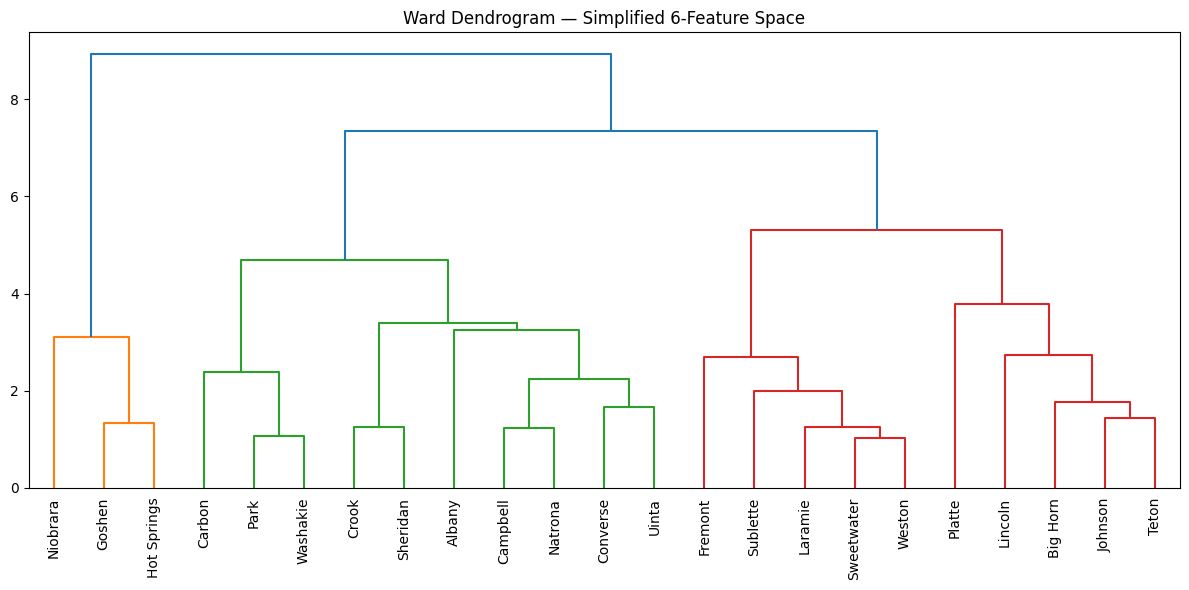

(6-feature) k=2  silhouette=0.359  cluster_sizes={1: 3, 2: 20}
(6-feature) k=3  silhouette=0.231  cluster_sizes={1: 3, 2: 10, 3: 10}
(6-feature) k=4  silhouette=0.219  cluster_sizes={1: 3, 2: 10, 3: 5, 4: 5}
(6-feature) k=5  silhouette=0.229  cluster_sizes={1: 3, 2: 3, 3: 7, 4: 5, 5: 5}
Saved PDF to: F:\Yellow Stone Flood-2022\floodanalysis\Data\Final Pre and Post Omicron\Ward_Dendrogram_6Feature.pdf


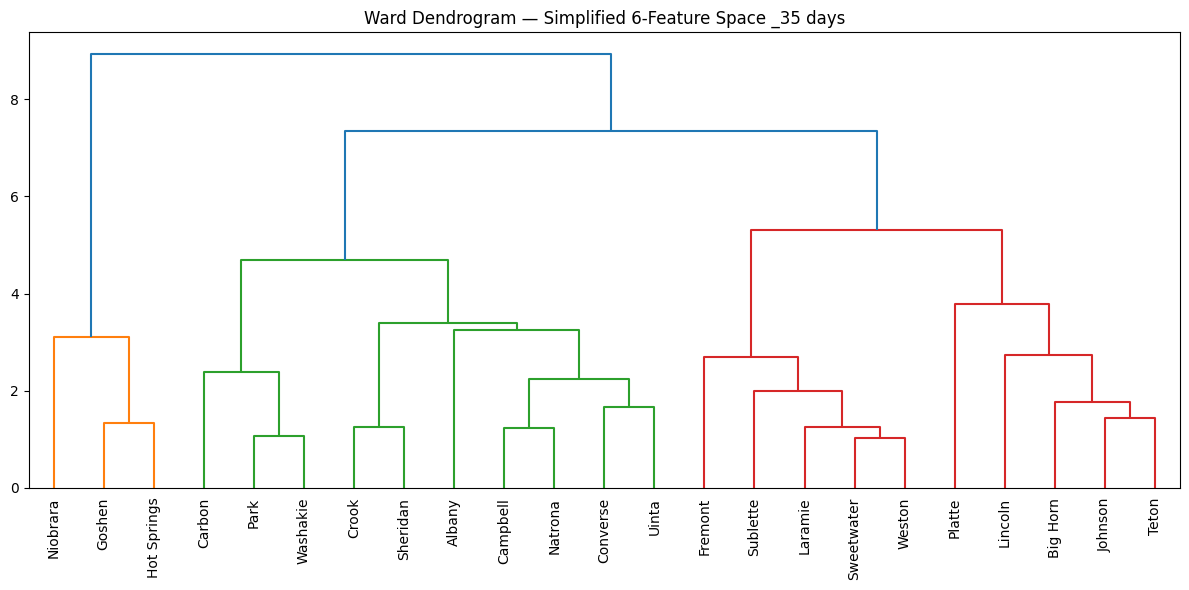

In [5]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
# --- Standardize ---
scaler = StandardScaler()
X6_scaled = scaler.fit_transform(df6.values)

# --- Ward linkage ---
Z6 = linkage(X6_scaled, method="ward")

# Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z6, labels=df6.index.tolist(), leaf_rotation=90)
plt.title("Ward Dendrogram — Simplified 6-Feature Space")
plt.tight_layout()
plt.show()

def assign_clusters(Z, k: int):
    return fcluster(Z, k, criterion="maxclust")

def silhouette_for_k(X, labels):
    if len(set(labels)) < 2:
        return np.nan
    return silhouette_score(X, labels)

for k in [2, 3, 4, 5]:
    labels = assign_clusters(Z6, k)
    score = silhouette_for_k(X6_scaled, labels)
    sizes = pd.Series(labels).value_counts().sort_index().to_dict()
    print(f"(6-feature) k={k}  silhouette={score:.3f}  cluster_sizes={sizes}")

# Better font embedding for PDF
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# Output folder
output_dir = r"F:\Yellow Stone Flood-2022\floodanalysis\Data\Final Pre and Post Omicron"
os.makedirs(output_dir, exist_ok=True)

output_pdf = os.path.join(output_dir, "Ward_Dendrogram_6Feature.pdf")

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Dendrogram
dendrogram(
    Z6,
    labels=df6.index.tolist(),
    leaf_rotation=90,
    ax=ax
)

ax.set_title("Ward Dendrogram — Simplified 6-Feature Space _35 days")
plt.tight_layout()

# Save as high-quality PDF
fig.savefig(
    output_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.05
)

print("Saved PDF to:", output_pdf)

plt.show()



In [6]:
k = 2  # <-- change after reviewing silhouette

labels = assign_clusters(Z6, k)

out6 = df6.copy()
out6["Cluster"] = labels

# Membership lists
members = out6.reset_index().groupby("Cluster")["County"].apply(list).sort_index()
print("Cluster members:")
for cl, lst in members.items():
    print(f"  Cluster {cl} ({len(lst)}): {lst}")

# Cluster means (raw units)
summary = out6.groupby("Cluster").mean(numeric_only=True)
print("\nCluster means (raw units):")
display(summary)

out6.sort_values("Cluster")


Cluster members:
  Cluster 1 (3): ['Goshen', 'Hot Springs', 'Niobrara']
  Cluster 2 (20): ['Albany', 'Big Horn', 'Campbell', 'Carbon', 'Converse', 'Crook', 'Fremont', 'Johnson', 'Laramie', 'Lincoln', 'Natrona', 'Park', 'Platte', 'Sheridan', 'Sublette', 'Sweetwater', 'Teton', 'Uinta', 'Washakie', 'Weston']

Cluster means (raw units):


,Lag_pre_mean,Lag_post_mean,Dist_pre_mean,Dist_post_mean,Mob_pre_mean,Mob_post_mean
Cluster,,,,,,
1,1.777778,1.611111,0.054934,0.069266,0.439716,0.458223
2,-3.333333,-2.766667,0.047533,0.066631,0.546474,0.543510


,Lag_pre_mean,Lag_post_mean,Dist_pre_mean,Dist_post_mean,Mob_pre_mean,Mob_post_mean,Cluster
County,,,,,,,
Goshen,1.000000,2.833333,0.053736,0.073092,0.458927,0.433471,1
Hot Springs,-0.333333,0.333333,0.054958,0.072162,0.437929,0.476695,1
Niobrara,4.666667,1.666667,0.056109,0.062543,0.422292,0.464503,1
Albany,-5.666667,-6.666667,0.043512,0.073332,0.598474,0.665106,2
Uinta,-4.333333,-4.666667,0.043433,0.064645,0.555261,0.578387,2
Teton,-5.000000,-3.666667,0.049827,0.067459,0.564219,0.515676,2
Sweetwater,-1.000000,-1.166667,0.045554,0.067412,0.514967,0.505664,2
Sublette,-2.333333,-1.333333,0.042443,0.063048,0.515104,0.516569,2
Sheridan,-3.666667,-4.666667,0.051791,0.061675,0.556700,0.599898,2
